In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

In [ ]:
# # Read and preprocess the data.
# import numpy as np
# import scipy.io
# import os
# from scipy.interpolate import interp1d


# print("Loading data...", flush=True)
# # Define the path to the .mat file
# file_path = os.path.join('MATLAB_DATA', 'results2.mat')

# # Load the .mat file
# mat_contents = scipy.io.loadmat(file_path)

# # Access the 'results' variable
# results = mat_contents['results']

# for result in results[0]:
#     # Scale the I values by 10^10
#     result['X'][0] = result['X'][0] * 10**10

# # Define a fixed length for resampling
# fixed_length = 1200  # Adjust based on the average length of your data

# # Initialize lists to hold the data
# X_data = []
# I_data = []
# B_MAG_data = []
# EDC_MAG_data = []

# # Function to resample and smooth data
# def resample_and_smooth(X, I, new_length):
#     # Define new X as evenly spaced values between 6562.5 and 6563.1
#     X_new = np.linspace(6562.5, 6563.1, num=new_length)
    
#     # Interpolate the I values over the new X values
#     f = interp1d(X, I, kind='cubic', fill_value="extrapolate")  # 'cubic' provides smoothing
#     I_new = f(X_new)
    
#     return X_new, I_new

# # Iterate through the results
# for result in results[0]:
#     B_MAG = result['B_MAG'][0]
#     EDC_MAG = result['EDC_MAG'][0]
#     X = result['X'][0] 
#     I = result['I'][0]
    
#     # print(f'B_MAG: {B_MAG}, EDC_MAG: {EDC_MAG}')

#     # Resample X and smooth I correspondingly
#     X_resampled, I_resampled = resample_and_smooth(X, I, fixed_length)
    
#     # Store the data in lists
#     X_data.append(X_resampled)
#     I_data.append(I_resampled)
#     B_MAG_data.append(B_MAG)
#     EDC_MAG_data.append(EDC_MAG)

# # Convert lists to numpy arrays
# X_data = np.array(X_data)
# I_data = np.array(I_data)
# B_MAG_data = np.array(B_MAG_data)
# EDC_MAG_data = np.array(EDC_MAG_data)

# print("Data loaded.", flush=True)

In [99]:
import scipy.io
import os
import numpy as np
from scipy.interpolate import interp1d

# Ask the user to input the name format
name_format = "FNN_large"
print("Run:", name_format)

# Function to generate file names based on the input format
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

print("Loading data...", flush=True)

# Define the paths to the .mat files
b_file_path = os.path.join('MATLAB_DATA', 'B.mat')
e_file_path = os.path.join('MATLAB_DATA', 'EDC.mat')
x_file_path = os.path.join('MATLAB_DATA', 'X.mat')
i_file_path = os.path.join('MATLAB_DATA', 'I.mat')

# Load the .mat files
b_contents = scipy.io.loadmat(b_file_path)
e_contents = scipy.io.loadmat(e_file_path)
x_contents = scipy.io.loadmat(x_file_path)
i_contents = scipy.io.loadmat(i_file_path)

# Access the variables from the loaded .mat files
B_MAG = b_contents['results1']
EDC_MAG = e_contents['results2']
X_data_raw = x_contents['results3']
I_data_raw = i_contents['results4']

# Scale the I values by 10^10 (assuming you still need this step)
for i in range(len(X_data_raw)):
    X_data_raw[i][0][0][0] = X_data_raw[i][0][0][0] * 10**10

# Define a fixed length for resampling
fixed_length = 1200  # Adjust based on the average length of your data

# Initialize lists to hold the resampled data
X_data = []
I_data = []
B_MAG_data = []
EDC_MAG_data = []
# Function to resample and smooth data
def resample_and_smooth(X, I, new_length):
    # Define new X as evenly spaced values between 6562.5 and 6563.1
    X_new = np.linspace(6562.5, 6563.1, num=new_length)
    
    # Interpolate the I values over the new X values
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")  # 'cubic' provides smoothing
    I_new = f(X_new)
    
    return X_new, I_new

# Iterate through the data and resample
for i in range(len(X_data_raw)):
    X = X_data_raw[i][0][0][0]
    I = I_data_raw[i][0][0][0]
    B = B_MAG[i][0][0][0]
    EDC = EDC_MAG[i][0][0][0]
    # Resample X and smooth I correspondingly
    X_resampled, I_resampled = resample_and_smooth(X, I, fixed_length)
    
    # Store the resampled data in lists
    X_data.append(X_resampled)
    I_data.append(I_resampled)
    B_MAG_data.append(B)
    EDC_MAG_data.append(EDC)

# Convert lists to numpy arrays
X_data = np.array(X_data)
I_data = np.array(I_data)
B_MAG_data = np.array(B_MAG_data)
EDC_MAG_data = np.array(EDC_MAG_data)

print("Data loaded and processed.", flush=True)


Loading data...


NotImplementedError: Please use HDF reader for matlab v7.3 files, e.g. h5py

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Flatten the I_data to use as input for the neural network
I_data_flat = I_data.reshape(I_data.shape[0], -1)

# Stack the B and E components to create the output (target) data
target_data = np.column_stack((B_MAG_data, EDC_MAG_data))  # B and E should have shape (n_samples, 3) each

# Split the data into training and testing sets
I_train, I_test, target_train, target_test = train_test_split(I_data_flat, target_data, test_size=0.2, random_state=42)

# Normalize the input data (I)
scaler_I = StandardScaler()
I_train = scaler_I.fit_transform(I_train)
I_test = scaler_I.transform(I_test)

# Normalize the target data (B and E)
scaler_B1 = StandardScaler()
scaler_B2 = StandardScaler()
scaler_B3 = StandardScaler()
scaler_E1 = StandardScaler()
scaler_E2 = StandardScaler()
scaler_E3 = StandardScaler()

B_train_scaled = np.column_stack((
    scaler_B1.fit_transform(B_train[:, 0].reshape(-1, 1)),
    scaler_B2.fit_transform(B_train[:, 1].reshape(-1, 1)),
    scaler_B3.fit_transform(B_train[:, 2].reshape(-1, 1))
))
B_test_scaled = np.column_stack((
    scaler_B1.transform(B_test[:, 0].reshape(-1, 1)),
    scaler_B2.transform(B_test[:, 1].reshape(-1, 1)),
    scaler_B3.transform(B_test[:, 2].reshape(-1, 1))
))

E_train_scaled = np.column_stack((
    scaler_E1.fit_transform(E_train[:, 0].reshape(-1, 1)),
    scaler_E2.fit_transform(E_train[:, 1].reshape(-1, 1)),
    scaler_E3.fit_transform(E_train[:, 2].reshape(-1, 1))
))

E_test_scaled = np.column_stack((
    scaler_E1.transform(E_test[:, 0].reshape(-1, 1)),
    scaler_E2.transform(E_test[:, 1].reshape(-1, 1)),
    scaler_E3.transform(E_test[:, 2].reshape(-1, 1))
))

# Combine the scaled B and E components for the test set
target_train_scaled = np.column_stack((B_train_scaled, E_train_scaled))
target_test_scaled = np.column_stack((B_test_scaled, E_test_scaled))


In [93]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import LeakyReLU
# Define the model architecture
# model = Sequential([
#     Input(shape=(I_train.shape[1],)),  # Input layer, matching the input data shape
    
#     Dense(512, activation='relu'),  # Increased the number of neurons
#     BatchNormalization(),
#     Dropout(0.4),
    
#     Dense(256, activation='relu'),  # Added more layers
#     BatchNormalization(),
#     Dropout(0.4),

#     Dense(128, activation='relu'),  # Original layers with more neurons
#     BatchNormalization(),
#     Dropout(0.4),

#     Dense(64, activation='relu'),
#     BatchNormalization(),
#     Dropout(0.3),

#     Dense(32, activation='relu'),
#     BatchNormalization(),
#     Dropout(0.3),
    
#     Dense(6)  # Output layer for 3 components each of B and E
# ])

model = Sequential([
    Input(shape=(I_train.shape[1],)),
    
    Dense(512),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(256),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(6)
])


import tensorflow as tf

def custom_loss(y_true, y_pred):
    # Split true and predicted values
    B_true, E_true = y_true[:, :3], y_true[:, 3:]
    B_pred, E_pred = y_pred[:, :3], y_pred[:, 3:]

    # Compute individual losses
    loss_B = tf.reduce_mean(tf.square(B_true - B_pred), axis=0)
    loss_E = tf.reduce_mean(tf.square(E_true - E_pred), axis=0)

    # Assign weights (adjust as needed)
    weight_B = tf.constant([0.1, 5.0, 1.0])  # You can adjust these weights
    weight_E = tf.constant([1.0, 1.0, 1.0])

    # Combine losses
    total_loss = tf.reduce_sum(weight_B * loss_B) + tf.reduce_sum(weight_E * loss_E)
    return total_loss

# Compile the model
# model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.compile(optimizer=Adam(learning_rate=0.0005), loss=custom_loss, metrics=['mae'])

# Define the learning rate scheduler and early stopping
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)


In [94]:
# Train the model with the callbacks
history = model.fit(
    I_train, 
    target_train_scaled, 
    epochs=200, 
    batch_size=32, 
    validation_split=0.2, 
    callbacks=[lr_scheduler, early_stopping]
)

Epoch 1/200
313/313 [==============================] - 8s 14ms/step - loss: 18.6228 - mae: 1.0956 - val_loss: 8.0785 - val_mae: 0.7453 - lr: 5.0000e-04
Epoch 2/200
313/313 [==============================] - 4s 13ms/step - loss: 11.5962 - mae: 0.8793 - val_loss: 7.4723 - val_mae: 0.7093 - lr: 5.0000e-04
Epoch 3/200
313/313 [==============================] - 4s 13ms/step - loss: 9.8435 - mae: 0.8136 - val_loss: 7.1382 - val_mae: 0.6917 - lr: 5.0000e-04
Epoch 4/200
313/313 [==============================] - 4s 13ms/step - loss: 8.7532 - mae: 0.7717 - val_loss: 7.0508 - val_mae: 0.6821 - lr: 5.0000e-04
Epoch 5/200
313/313 [==============================] - 4s 13ms/step - loss: 8.2314 - mae: 0.7514 - val_loss: 6.8932 - val_mae: 0.6734 - lr: 5.0000e-04
Epoch 6/200
313/313 [==============================] - 4s 13ms/step - loss: 7.8021 - mae: 0.7323 - val_loss: 6.8027 - val_mae: 0.6669 - lr: 5.0000e-04
Epoch 7/200
313/313 [==============================] - 4s 13ms/step - loss: 7.5830 - mae: 0.

In [84]:
import os

# Define the file path for saving the model
model_save_path = os.path.join("/p/ltxdata/DFSS/machine learning", generate_filename("model", "h5"))

# Save the trained model
model.save(model_save_path)
print("Model saved successfully.")



Model saved successfully.


In [85]:
from tensorflow.keras.models import load_model
# Load the saved model
model_save_path = os.path.join("/p/ltxdata/DFSS/machine learning", generate_filename("model", "h5"))
# model = load_model(model_save_path)
model = load_model(model_save_path, custom_objects={'custom_loss': custom_loss})
print("Model loaded successfully.")


Model loaded successfully.


In [95]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Choose a subset of the training data for evaluation
train_subset_indices = np.random.choice(len(I_train), size=1000, replace=False)
train_input_data_subset = I_train[train_subset_indices]
train_target_data_subset = target_train_scaled[train_subset_indices]

# Generate predictions
predictions_train = model.predict(train_input_data_subset)

# Inverse transform the predictions to get original units
B_pred_train = scaler_B.inverse_transform(predictions_train[:, :3])
E_pred_train = scaler_E.inverse_transform(predictions_train[:, 3:])
predictions_train_original = np.column_stack((B_pred_train, E_pred_train))

# Inverse transform the true values
B_true_train = scaler_B.inverse_transform(train_target_data_subset[:, :3])
E_true_train = scaler_E.inverse_transform(train_target_data_subset[:, 3:])
true_values_train_original = np.column_stack((B_true_train, E_true_train))

# Calculate evaluation metrics
mae_train = mean_absolute_error(true_values_train_original, predictions_train_original)
rmse_train = np.sqrt(mean_squared_error(true_values_train_original, predictions_train_original))
r2_train = r2_score(true_values_train_original, predictions_train_original)

def normalized_root_mean_squared_error(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return rmse / (y_true.max() - y_true.min())

nrmse_train = normalized_root_mean_squared_error(true_values_train_original, predictions_train_original)

print(f'NRMSE (Train): {nrmse_train:.2f}')
print(f'Mean Absolute Error (MAE, Train): {mae_train}')
print(f'Root Mean Squared Error (RMSE, Train): {rmse_train}')
print(f'R^2 Score (Train): {r2_train}')

# Save evaluation metrics to a text file
metrics_train_file = os.path.join("/p/ltxdata/DFSS/machine learning", generate_filename("evaluation_metrics_train", "txt"))
with open(metrics_train_file, "w") as f:
    f.write(f"Mean Absolute Error (MAE): {mae_train}\n")
    f.write(f"Root Mean Squared Error (RMSE): {rmse_train}\n")
    f.write(f"R^2 Score: {r2_train}\n")
    f.write(f"Normalized RMSE (NRMSE): {nrmse_train}\n")


32/32 [==============================] - 0s 3ms/step
NRMSE (Train): 0.13
Mean Absolute Error (MAE, Train): 127.93004111313171
Root Mean Squared Error (RMSE, Train): 235.54310491497532
R^2 Score (Train): 0.5056370739269154


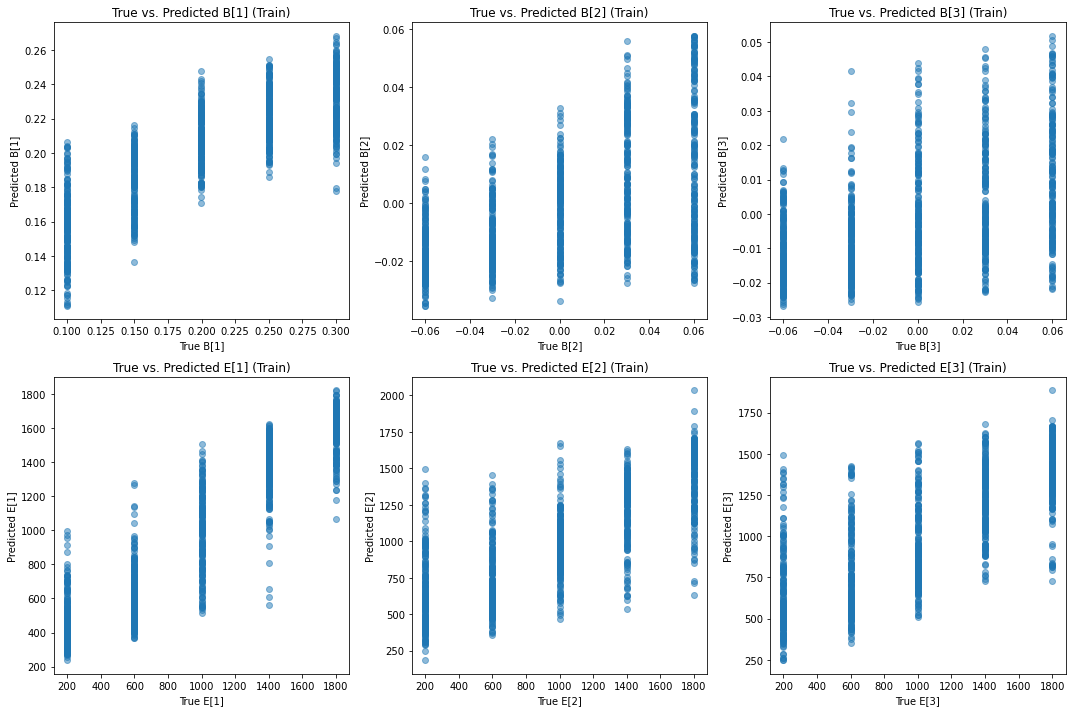

In [96]:
import matplotlib.pyplot as plt

# Plot the true vs. predicted B and E values for the training set
plt.figure(figsize=(15, 10))

# Plotting for B components
for i in range(3):
    plt.subplot(2, 3, i+1)
    plt.scatter(true_values_train_original[:, i], predictions_train_original[:, i], alpha=0.5)
    plt.xlabel(f'True B[{i+1}]')
    plt.ylabel(f'Predicted B[{i+1}]')
    plt.title(f'True vs. Predicted B[{i+1}] (Train)')

# Plotting for E components
for i in range(3):
    plt.subplot(2, 3, i+4)
    plt.scatter(true_values_train_original[:, i+3], predictions_train_original[:, i+3], alpha=0.5)
    plt.xlabel(f'True E[{i+1}]')
    plt.ylabel(f'Predicted E[{i+1}]')
    plt.title(f'True vs. Predicted E[{i+1}] (Train)')

plt.tight_layout()

figure_train_file = os.path.join("/p/ltxdata/DFSS/machine learning", generate_filename("true_vs_predictions_train", "png"))
plt.savefig(figure_train_file, dpi=300, facecolor='white')
plt.show()
plt.close()


In [97]:
# Generate predictions for the test set
predictions_test = model.predict(I_test)

# Inverse transform the predictions to get original units
B_pred_test = scaler_B.inverse_transform(predictions_test[:, :3])
E_pred_test = scaler_E.inverse_transform(predictions_test[:, 3:])
predictions_test_original = np.column_stack((B_pred_test, E_pred_test))

# Inverse transform the true values
B_true_test = scaler_B.inverse_transform(target_test_scaled[:, :3])
E_true_test = scaler_E.inverse_transform(target_test_scaled[:, 3:])
true_values_test_original = np.column_stack((B_true_test, E_true_test))

# Calculate evaluation metrics
mae_test = mean_absolute_error(true_values_test_original, predictions_test_original)
rmse_test = np.sqrt(mean_squared_error(true_values_test_original, predictions_test_original))
r2_test = r2_score(true_values_test_original, predictions_test_original)
nrmse_test = normalized_root_mean_squared_error(true_values_test_original, predictions_test_original)

print(f'NRMSE (Test): {nrmse_test:.2f}')
print(f'Mean Absolute Error (MAE, Test): {mae_test}')
print(f'Root Mean Squared Error (RMSE, Test): {rmse_test}')
print(f'R^2 Score (Test): {r2_test}')

# Save evaluation metrics to a text file
metrics_test_file = os.path.join("/p/ltxdata/DFSS/machine learning", generate_filename("evaluation_metrics_test", "txt"))
with open(metrics_test_file, "w") as f:
    f.write(f"Mean Absolute Error (MAE): {mae_test}\n")
    f.write(f"Root Mean Squared Error (RMSE): {rmse_test}\n")
    f.write(f"R^2 Score: {r2_test}\n")
    f.write(f"Normalized RMSE (NRMSE): {nrmse_test}\n")


98/98 [==============================] - 0s 3ms/step
NRMSE (Test): 0.13
Mean Absolute Error (MAE, Test): 128.85772724632446
Root Mean Squared Error (RMSE, Test): 234.39491414607437
R^2 Score (Test): 0.49592421980887164


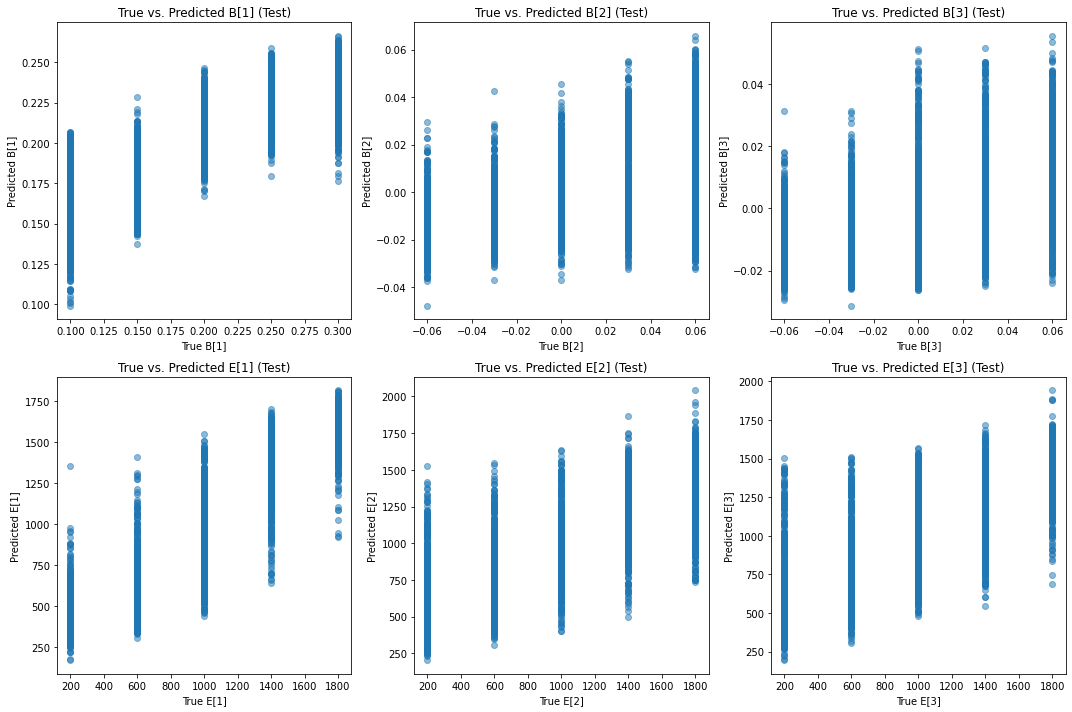

In [98]:
# Plot the true vs. predicted B and E values for the test set
plt.figure(figsize=(15, 10))

# Plotting for B components
for i in range(3):
    plt.subplot(2, 3, i+1)
    plt.scatter(true_values_test_original[:, i], predictions_test_original[:, i], alpha=0.5)
    plt.xlabel(f'True B[{i+1}]')
    plt.ylabel(f'Predicted B[{i+1}]')
    plt.title(f'True vs. Predicted B[{i+1}] (Test)')

# Plotting for E components
for i in range(3):
    plt.subplot(2, 3, i+4)
    plt.scatter(true_values_test_original[:, i+3], predictions_test_original[:, i+3], alpha=0.5)
    plt.xlabel(f'True E[{i+1}]')
    plt.ylabel(f'Predicted E[{i+1}]')
    plt.title(f'True vs. Predicted E[{i+1}] (Test)')

plt.tight_layout()

figure_test_file = os.path.join("/p/ltxdata/DFSS/machine learning", generate_filename("true_vs_predictions_train", "png"))
plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()
plt.close()
